In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\obd_cleaned.csv')
print("Shape:", df.shape)
print("Driving style distribution:")
print(df['DRIVING_STYLE'].value_counts())

Shape: (47514, 30)
Driving style distribution:
DRIVING_STYLE
IDLE          20535
NORMAL        14505
ECO            8061
AGGRESSIVE     4413
Name: count, dtype: int64


Classes: ['AGGRESSIVE' 'ECO' 'IDLE' 'NORMAL']
Train: (38011, 12), Test: (9503, 12)

📊 Classification Report:
              precision    recall  f1-score   support

  AGGRESSIVE       1.00      1.00      1.00       883
         ECO       1.00      1.00      1.00      1612
        IDLE       1.00      1.00      1.00      4107
      NORMAL       1.00      1.00      1.00      2901

    accuracy                           1.00      9503
   macro avg       1.00      1.00      1.00      9503
weighted avg       1.00      1.00      1.00      9503



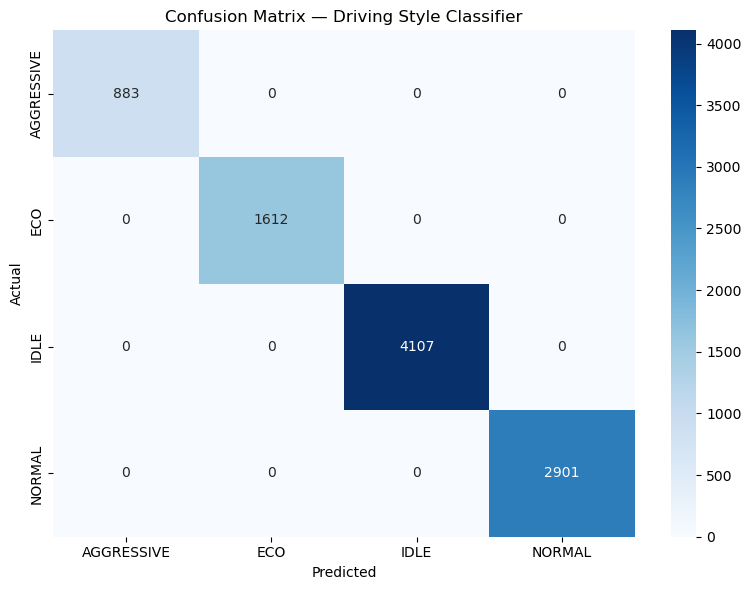

✅ Saved: confusion_matrix.png


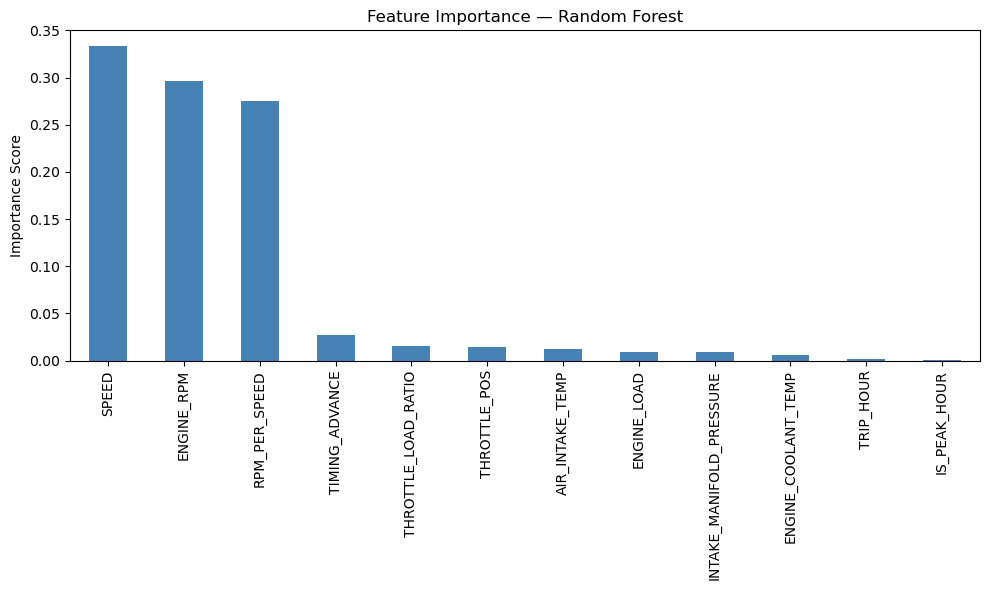

✅ Saved: feature_importance.png

Top 3 features: ['SPEED', 'ENGINE_RPM', 'RPM_PER_SPEED']


In [3]:
# ── STEP 1: Feature selection ─────────────────────────────────────────
features = ['SPEED', 'ENGINE_RPM', 'THROTTLE_POS', 'ENGINE_LOAD',
            'ENGINE_COOLANT_TEMP', 'AIR_INTAKE_TEMP',
            'INTAKE_MANIFOLD_PRESSURE', 'TIMING_ADVANCE',
            'RPM_PER_SPEED', 'THROTTLE_LOAD_RATIO', 'TRIP_HOUR',
            'IS_PEAK_HOUR']

target = 'DRIVING_STYLE'

X = df[features]
y = df[target]

# ── STEP 2: Encode target ─────────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)

# ── STEP 3: Train/test split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── STEP 4: Scale features ────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── STEP 5: Train Random Forest ───────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# ── STEP 6: Evaluate ──────────────────────────────────────────────────
y_pred = rf.predict(X_test_scaled)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── STEP 7: Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Driving Style Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png")

# ── STEP 8: Feature importance ────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\feature_importance.png', dpi=150)
plt.show()
print("✅ Saved: feature_importance.png")
print("\nTop 3 features:", importances.head(3).index.tolist())

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import pickle

# ── XGBoost Model ─────────────────────────────────────────────────────
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

print("📊 XGBoost Classification Report:")
print(classification_report(xgb_pred, y_test, target_names=le.classes_))
print("XGBoost Accuracy:", round(accuracy_score(y_test, xgb_pred)*100, 2), "%")

# ── Save both models ──────────────────────────────────────────────────
pickle.dump(rf, open(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\rf_model.pkl', 'wb'))
pickle.dump(xgb, open(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\xgb_model.pkl', 'wb'))
pickle.dump(scaler, open(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\scaler.pkl', 'wb'))
pickle.dump(le, open(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\label_encoder.pkl', 'wb'))
print("✅ All models saved!")

# ── Safety Score per vehicle ──────────────────────────────────────────
safety = df.groupby('VEHICLE_ID').agg(
    total_readings = ('SPEED', 'count'),
    avg_speed      = ('SPEED', 'mean'),
    avg_rpm        = ('ENGINE_RPM', 'mean'),
    aggressive_pct = ('DRIVING_STYLE', lambda x: (x=='AGGRESSIVE').mean()*100),
    fault_total    = ('FAULT_COUNT', 'sum')
).round(2)

safety['safety_score'] = (
    100 -
    (safety['aggressive_pct'] * 0.5) -
    (safety['avg_speed'] / 120 * 30) -
    (safety['fault_total'].clip(upper=100) * 0.2)
).round(2)

safety['safety_label'] = safety['safety_score'].apply(
    lambda x: 'SAFE' if x >= 80 else ('MODERATE' if x >= 60 else 'RISKY'))

print("\n🏆 Driver Safety Scores:")
print(safety[['avg_speed','aggressive_pct','fault_total',
              'safety_score','safety_label']].sort_values('safety_score'))

safety.to_csv(r'C:\Users\AmalDev\Downloads\obd-driver-behavior\safety_scores.csv')
print("✅ Saved: safety_scores.csv")

📊 XGBoost Classification Report:
              precision    recall  f1-score   support

  AGGRESSIVE       1.00      1.00      1.00       884
         ECO       1.00      1.00      1.00      1612
        IDLE       1.00      1.00      1.00      4107
      NORMAL       1.00      1.00      1.00      2900

    accuracy                           1.00      9503
   macro avg       1.00      1.00      1.00      9503
weighted avg       1.00      1.00      1.00      9503

XGBoost Accuracy: 99.91 %
✅ All models saved!

🏆 Driver Safety Scores:
            avg_speed  aggressive_pct  fault_total  safety_score safety_label
VEHICLE_ID                                                                   
car11           55.33           31.42            0         70.46     MODERATE
car6            25.22            3.78         6071         71.81     MODERATE
car7            23.21           14.79           58         75.20     MODERATE
car13           28.33           21.36            0         82.24       